## **TELECOM CHURN PREDICTOR - FINAL MODEL**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
import shap
import joblib

In [2]:
df=pd.read_csv("C:/Users/chiboy/telecom_churn_project/data/processed/telecom_churn_cleaned.csv")

### DATA PREPOCESSING

In [3]:
# 1. Prepare features and target
feature_columns = [
    'tenure', 
    'MonthlyCharges', 
    'TotalCharges', 
    'Contract',
    'InternetService', 
    'OnlineSecurity', 
    'TechSupport', 
    'PaperlessBilling',
    'PaymentMethod',
    'AvgMonthlySpend',
    'TenureGroup'
]
X = df[feature_columns]
y = df['Churn'].map({'Yes': 1, 'No': 0})

In [4]:
# 2. Handle categorical features
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

C:\Users\chiboy\AppData\Local\Temp\ipykernel_73444\1802314722.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object', 'category']).columns


In [5]:
# 3. Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
# 4. Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# 5. Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"After SMOTE - Train shape: {X_train_resampled.shape}")
print(f"After SMOTE - Churn: {y_train_resampled.mean():.2%}")

After SMOTE - Train shape: (8260, 11)
After SMOTE - Churn: 50.00%


### MODEL TRAINING

In [8]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_resampled, y_train_resampled)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [9]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

In [10]:
roc_auc = roc_auc_score(y_test, y_proba)
print(f"\n{'='*60}")
print("MODEL PERFORMANCE")
print("="*60)
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


MODEL PERFORMANCE
ROC-AUC: 0.8283

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.72      0.74      1407


Confusion Matrix:
[[720 313]
 [ 75 299]]


### SHAP ANALYSIS

In [11]:
explainer = shap.LinearExplainer(model, X_train_scaled, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test_scaled)

# Feature names
feature_names = X.columns.tolist()

C:\Users\chiboy\telecom_churn_project\venv\Lib\site-packages\shap\explainers\_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)
Background dataset has 5625 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5625 when initializing the masker.


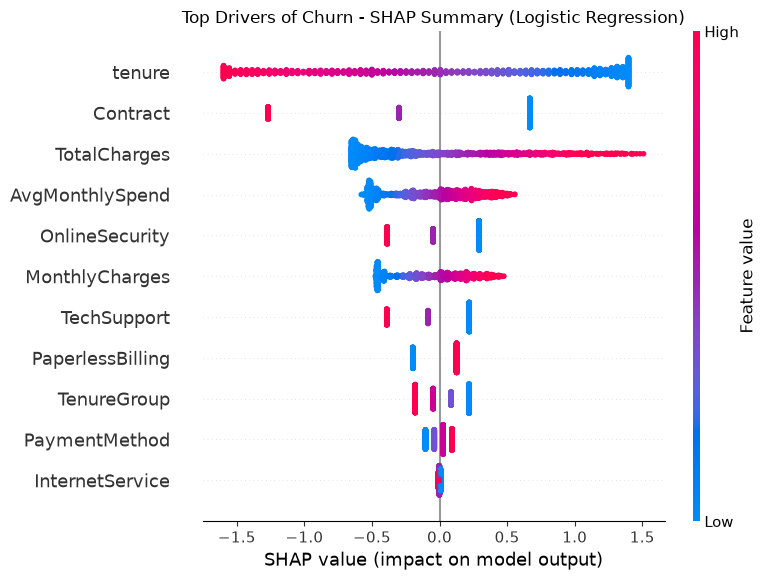

In [12]:
# 1. Summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, show=False)
plt.title('Top Drivers of Churn - SHAP Summary (Logistic Regression)')
plt.tight_layout()
plt.savefig('C:/Users/chiboy/telecom_churn_project/reports/shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

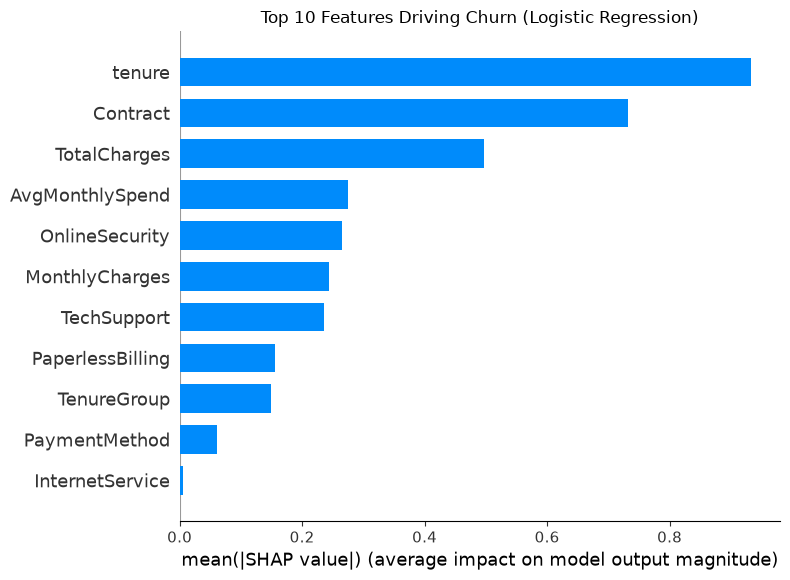

In [13]:
# 2. Bar plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, 
                  plot_type="bar", show=False)
plt.title('Top 10 Features Driving Churn (Logistic Regression)')
plt.tight_layout()
plt.savefig('C:/Users/chiboy/telecom_churn_project/reports/shap_bar.png', dpi=300, bbox_inches='tight')
plt.show()

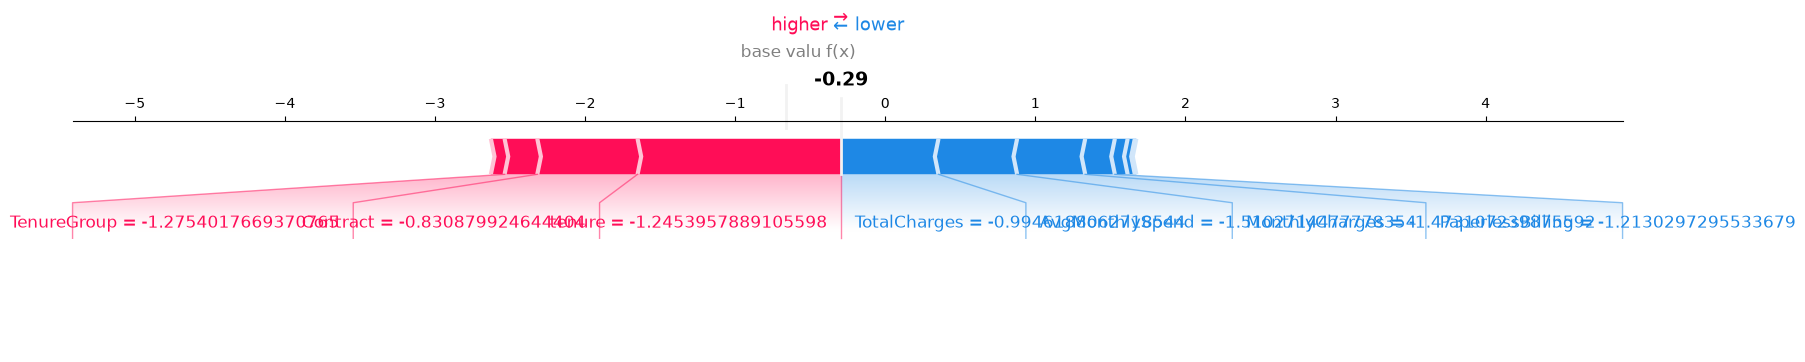

In [14]:
# 3. Individual prediction explanation
# Example: Pick a churned customer
churned_idx = np.where(y_test == 1)[0][0]
shap.force_plot(explainer.expected_value, shap_values[churned_idx], 
                X_test_scaled[churned_idx], feature_names=feature_names, 
                matplotlib=True, show=False)
plt.savefig('C:/Users/chiboy/telecom_churn_project/reports/shap_force_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### SAVE MODEL

In [15]:
# Save model and scaler
joblib.dump(model, 'C:/Users/chiboy/telecom_churn_project/models/best_churn_model.pkl')
joblib.dump(scaler, 'C:/Users/chiboy/telecom_churn_project/models/scaler.pkl')
joblib.dump(feature_names, 'C:/Users/chiboy/telecom_churn_project/models/feature_names.pkl')

['C:/Users/chiboy/telecom_churn_project/models/feature_names.pkl']

### FEATURE EVALUATION

In [16]:
# FEATURE IMPORTANCE
coefficients = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': model.coef_[0],
    'Abs_Coefficient': np.abs(model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("\nTop Features:")
print(coefficients)


Top Features:
             Feature  Coefficient  Abs_Coefficient
0             tenure    -1.035583         1.035583
3           Contract    -0.807450         0.807450
2       TotalCharges     0.568733         0.568733
9    AvgMonthlySpend     0.322570         0.322570
5     OnlineSecurity    -0.293164         0.293164
1     MonthlyCharges     0.285350         0.285350
6        TechSupport    -0.263261         0.263261
10       TenureGroup    -0.162708         0.162708
7   PaperlessBilling     0.158953         0.158953
8      PaymentMethod     0.069512         0.069512
4    InternetService    -0.006036         0.006036


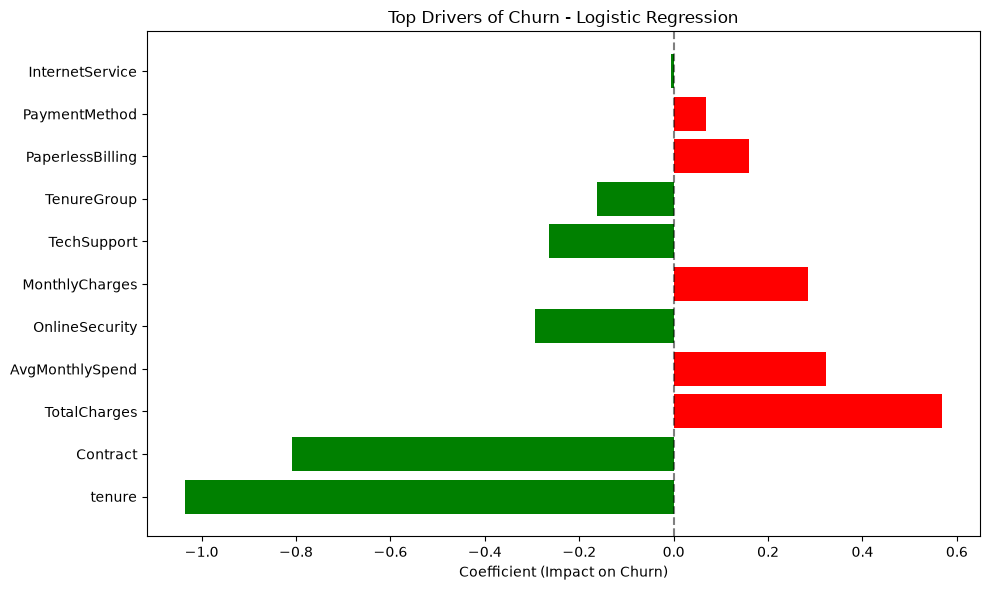

In [17]:
# Visualize
plt.figure(figsize=(10, 6))
colors = ['red' if x > 0 else 'green' for x in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Coefficient (Impact on Churn)')
plt.title('Top Drivers of Churn - Logistic Regression')
plt.tight_layout()
plt.savefig('C:/Users/chiboy/telecom_churn_project/reports/final_feature_importance.png', dpi=300)
plt.show()

#### ROC CURVE

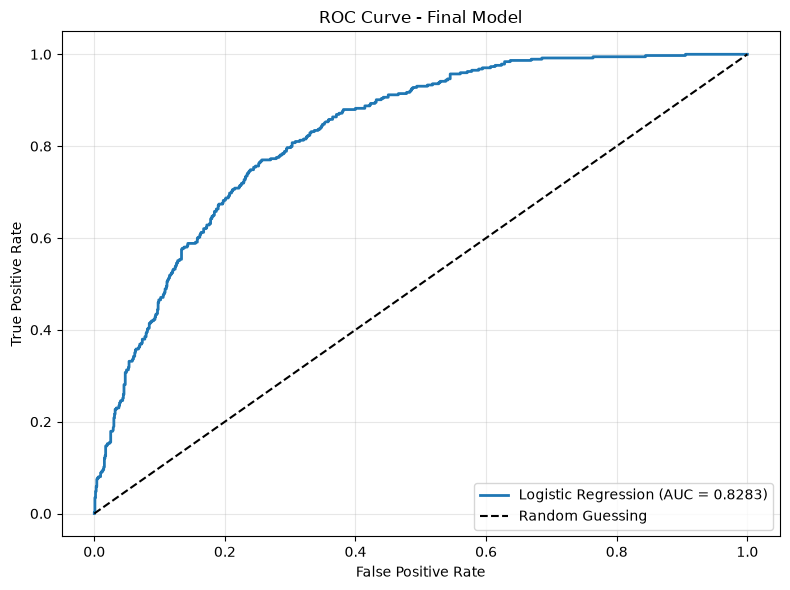

In [18]:
# 6. ROC CURVE
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Final Model')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('C:/Users/chiboy/telecom_churn_project/reports/final_roc_curve.png', dpi=300)
plt.show()